<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">🎙️Predict 🎤Podcast Listening👂 Time⌚
</h1>  
     
</div>

<p><center style="color:blue; font-family: 'Dancing Script'; font-size:30px;">🙏🏿Thanks for visiting my notebook 🕺🏿</center></p>

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: white; font-size:100%; text-align:left">

<h3 align="center"><font color='#DAA520'>💡 About The Competition :</font></h3>
    
**Dataset Description** The dataset for this competition (both train and test) was generated from a deep learning model trained on the Podcast Listening Time Prediction dataset.

**Files**

train.csv – The training dataset; Listening_Time_minutes is the target variable.

test.csv – The test dataset; our objective is to predict Listening_Time_minutes for each of the row.

**sample_submission.csv** – A sample submission file in the correct format.

Exploration We got to Explore differences between this dataset and the original Podcast Listening Time Prediction dataset. Through analysis whether incorporating the original dataset into training improves model performance. Got to go with visualization techniques for Exploratory Data Analysis (EDA), including feature distributions and correlations for better undersatding of data Analyze patterns related to podcast duration, genre, user behavior, and other factors affecting listening time.

**Evaluation The model will be evaluated using Root Mean Squared Error (RMSE).**

Submission train.csv – Training dataset with Listening_Time_minutes labels. test.csv – Test dataset without Listening_Time_minutes labels. sample_submission.csv – Required submission format.

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: lightgrey; font-size:100%; text-align:left">

<h3 align="center"><font color='black'>💡 Evalaution Metric :</font></h3>
    
    
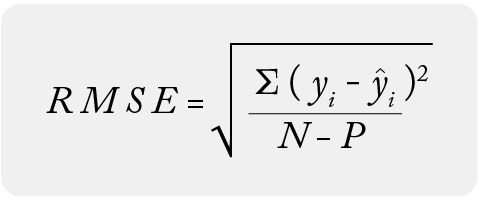
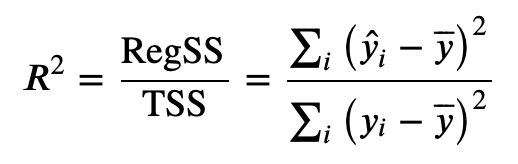
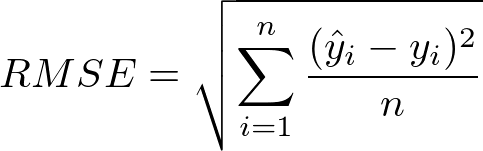
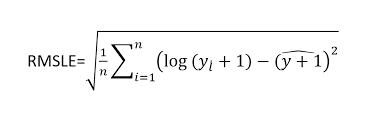
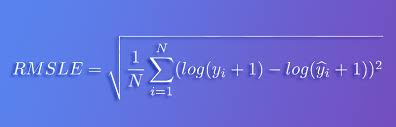
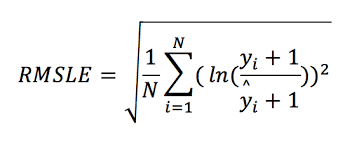

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Importing Libraries</h1>  
     
</div>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')
df_test  = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')
df_sub = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

In [ ]:
df_train.head()

In [ ]:
df_train.describe()

In [ ]:
df_test.head()

In [ ]:
df_sub.head()

In [ ]:
df_train.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)


In [ ]:
df_train.shape,df_test.shape

In [ ]:
df_train.isnull().sum()

In [ ]:
df_test.isnull().sum()

In [ ]:
df_train.shape,df_test.shape,df_sub.shape

In [ ]:
df_train.corr()

In [ ]:
df_train.dtypes

In [ ]:
common_cols = df_train.columns.intersection(df_test.columns)

numerical_cols = df_train[common_cols].select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_train[common_cols].select_dtypes(include=['object']).columns

df_train[numerical_cols] = df_train[numerical_cols].fillna(df_train[numerical_cols].median())
df_test[numerical_cols] = df_test[numerical_cols].fillna(df_train[numerical_cols].median())
df_train[categorical_cols] = df_train[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))
df_test[categorical_cols] = df_test[categorical_cols].apply(lambda x: x.fillna(df_train[x.name].mode()[0]))

In [ ]:
common_cols = df_train.columns.intersection(df_test.columns)
categorical_cols = df_train[common_cols].select_dtypes(include=['object']).columns

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Regression Analysis♒🌊</h1>  
     
</div>

In [ ]:
y = df_train['Listening_Time_minutes'] 

In [ ]:
df_train = pd.read_csv('/kaggle/input/interstellarspacetri/datap/train.csv')
df_test  = pd.read_csv('/kaggle/input/interstellarspacetri/datap/test.csv')

In [ ]:
X = df_train
X_test = df_test

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
import gc
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool
import xgboost as xgb

In [ ]:
encoded_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

xgb_params = {
    'n_estimators': 565,
    'max_depth': 14,
    'learning_rate': 0.04222221,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,    
    'tree_method':'gpu_hist', 
    'n_jobs': -1  
}


n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
scores = []
test_preds = np.zeros(len(X_test)) 

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"Training fold {fold + 1}/{n_splits}...")    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]   
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=100, verbose=100)    
    val_pred = model.predict(X_val)
    score = rmse(y_val, val_pred)
    scores.append(score)
    test_preds += model.predict(X_test) / n_splits      
    print(f"Fold {fold + 1} RMSE: {score:.4f}")
print(f'Optimized Cross-validated RMSE score: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')
print(f'Max RMSE score: {np.max(scores):.3f}')
print(f'Min RMSE score: {np.min(scores):.3f}')

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🎇🌭Plots from results for XGboost♒🌊</h1>  
     
</div>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Feature Importance (XGBoost)")
axes[0, 0].set_xlabel("Importance Score")
axes[0, 0].set_ylabel("Features")

sns.scatterplot(x=y_val, y=val_pred, alpha=0.6, edgecolors="k", ax=axes[0, 1])
axes[0, 1].plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], '--r', linewidth=2) 
axes[0, 1].set_title("Actual vs. Predicted Listening Time")
axes[0, 1].set_xlabel("Actual Values")
axes[0, 1].set_ylabel("Predicted Values")

residuals = y_val - val_pred
sns.histplot(residuals, bins=30, kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")

sns.histplot(test_preds, bins=30, kde=True, color='green', ax=axes[1, 1])
axes[1, 1].set_title("Test Predictions Distribution")
axes[1, 1].set_xlabel("Predicted Listening Time")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:

df_sub.head()

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">🗞📜Final Submission♒🌊</h1>  
     
</div>

In [ ]:
df_sub['Listening_Time_minutes'] = test_preds

In [ ]:
df_sub.to_csv('submission.csv', index=False)

In [ ]:
df_sub.head()

In [ ]:
df_sub['Listening_Time_minutes'].hist()